In [1]:
#Load packages
%matplotlib inline
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle,ConnectionPatch
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import pandas as pd
typeface='Helvetica Neue'
mpl.rcParams['font.weight']=300
mpl.rcParams['axes.labelweight']=300
mpl.rcParams['font.family']=typeface
mpl.rcParams['font.size']=22
mpl.rcParams['pdf.fonttype']=42

import os,glob
import numpy as np
import baltic as bt
import json
import csv

def hpd(data, level): #Thanks Gytis Dudas for this
    """
    Return highest posterior density interval from a list,
    given the percent posterior density interval required.
    """
    d = list(data)
    d.sort()

    nData = len(data)
    nIn = int(round(level * nData))
    if nIn < 2 :
        return None
    #raise RuntimeError("Not enough data. N data: %s"%(len(data)))
 
    i = 0
    r = d[i+nIn-1] - d[i]
    for k in range(len(d) - (nIn - 1)) :
        rk = d[k+nIn-1] - d[k]
        if rk < r :
            r = rk
            i = k

    assert 0 <= i <= i+nIn-1 < len(d)
 
    return (d[i], d[i+nIn-1])

def decimal_year_to_date(decimal_year):
    year = int(decimal_year)  # Get the integer part as the year
    remainder = decimal_year - year  # Get the decimal/fractional part
    start_of_year = pd.Timestamp(f'{year}-01-01')  # Start of the year
    # Calculate the date by adding the fractional part as days
    days_in_year = (pd.Timestamp(f'{year + 1}-01-01') - start_of_year).days
    date = start_of_year + pd.to_timedelta(remainder * days_in_year, unit='D')
    return date

In [28]:
#TMRCA statistics

TMRCA = []

with open("/Users/ricardorivero/Documents/DENV/2024/D2/F1112/F112__markov_newseqs.aligned.log","r") as f:
    reader = csv.DictReader(f, delimiter="\t")
    print(reader.fieldnames)
    for row in reader:
        mrca = float(row['age(root)'])
        TMRCA.append(mrca)

TMRCA_data = pd.DataFrame(TMRCA,columns=['TMRCA'])
#Filter data outside the HPD95
print(np.mean(TMRCA_data['TMRCA']))
data = TMRCA_data['TMRCA']
hpdLo,hpdHi=hpd(data,0.95)
print(hpdLo,hpdHi)

['state', 'joint', 'prior', 'likelihood', 'age(root)', 'treeLength', 'location.clock.rate', 'location.meanRate', 'location.rates.Bangladesh.Bolivia', 'location.rates.Bangladesh.Brazil', 'location.rates.Bangladesh.Colombia', 'location.rates.Bangladesh.Ecuador', 'location.rates.Bangladesh.Paraguay', 'location.rates.Bangladesh.Peru', 'location.rates.Bangladesh.USA', 'location.rates.Bolivia.Brazil', 'location.rates.Bolivia.Colombia', 'location.rates.Bolivia.Ecuador', 'location.rates.Bolivia.Paraguay', 'location.rates.Bolivia.Peru', 'location.rates.Bolivia.USA', 'location.rates.Brazil.Colombia', 'location.rates.Brazil.Ecuador', 'location.rates.Brazil.Paraguay', 'location.rates.Brazil.Peru', 'location.rates.Brazil.USA', 'location.rates.Colombia.Ecuador', 'location.rates.Colombia.Paraguay', 'location.rates.Colombia.Peru', 'location.rates.Colombia.USA', 'location.rates.Ecuador.Paraguay', 'location.rates.Ecuador.Peru', 'location.rates.Ecuador.USA', 'location.rates.Paraguay.Peru', 'location.rate

<Axes: xlabel='TMRCA', ylabel='Density'>

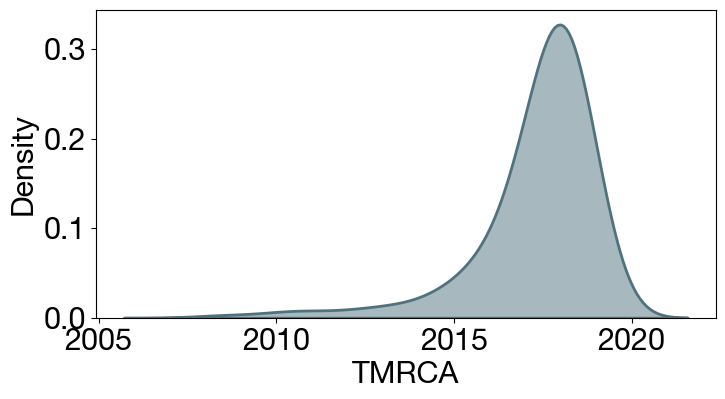

In [23]:
#Plot density plot with seaborn
#compute density
from scipy.stats import gaussian_kde
import seaborn as sns
from scipy.stats import norm

from sklearn.neighbors import KernelDensity


# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 4), facecolor='w', frameon=False)

# Plot the data
sns.kdeplot(ax, x=TMRCA_data['TMRCA'], color='#50727F', linewidth=2, fill=True, alpha=0.5, bw_adjust=3, )


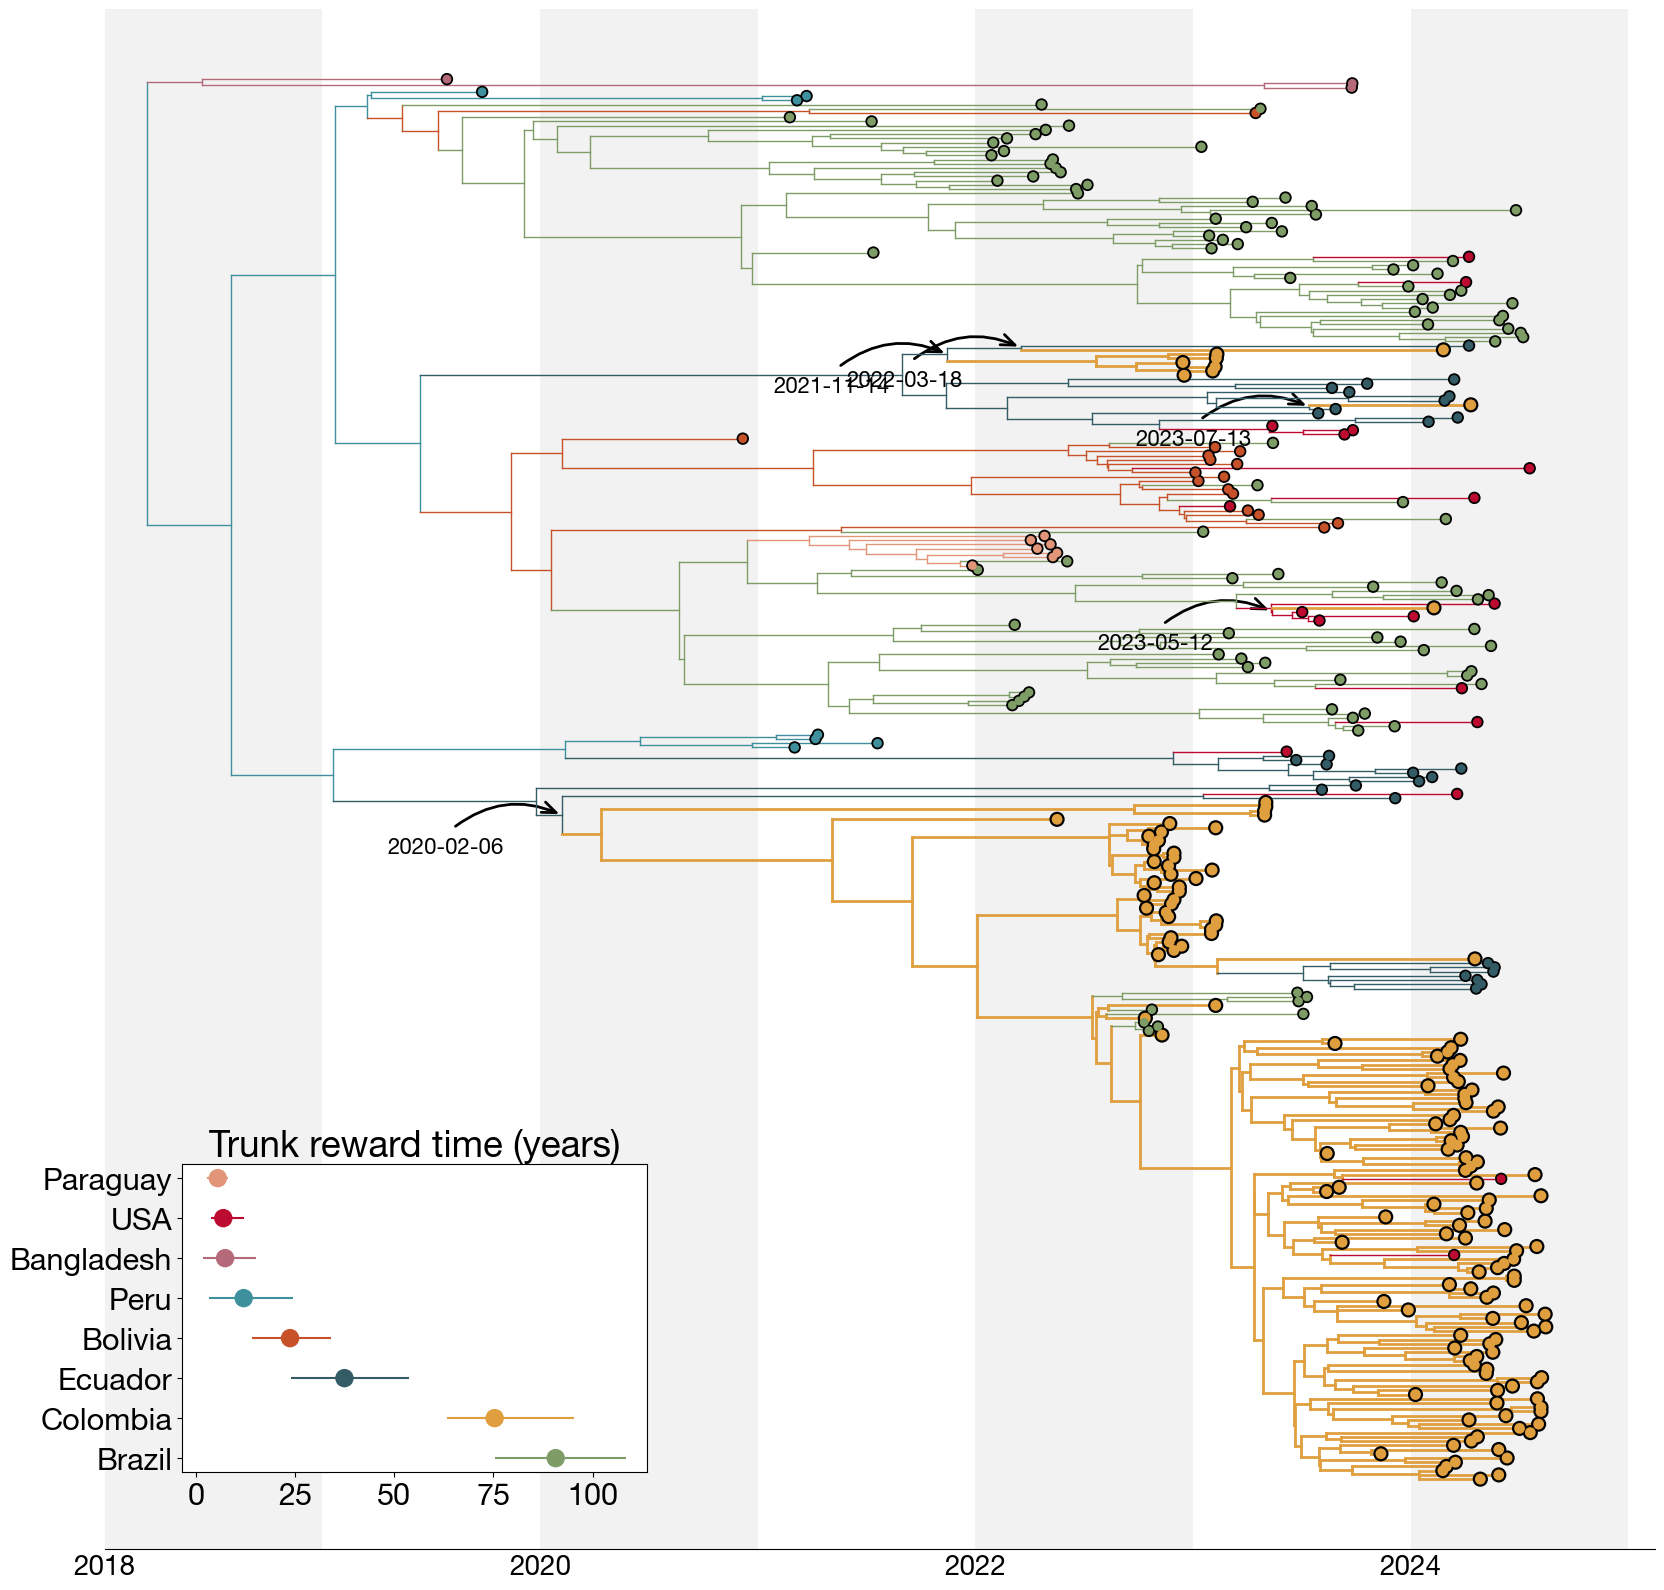

In [16]:
import baltic as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch

# Load the tree
treePath = '/Users/ricardorivero/Documents/DENV/2024/D2/F1112/F112__markov_newseqs.aligned.mcc.tree'
ll = bt.loadNexus(treePath, absoluteTime=True, sortBranches=True)

# Define color and label dictionaries
colors = {
    "Bolivia": "#c7522a",
    "Brazil": "#7e9c66",
    "Colombia": "#e09f3e",
    "Ecuador": "#335c67",
    "Paraguay": "#e29578",
    "Peru": "#3e909d",
    "USA": "#bd0a31",
    "Bangladesh": "#B56A7A"
}

# Function to detect introductions into Colombia
def introductions_into_colombia(k):
    return 'location' in k.traits and k.traits['location'] == 'Colombia'

# Function to plot a curved arrow pointing to a node
def plot_curved_arrow(ax, start_x, start_y, end_x, end_y):
    arrow = FancyArrowPatch((start_x, start_y), (end_x, end_y), 
                            connectionstyle="arc3,rad=-0.3",  # Creates a curve
                            color='black', 
                            arrowstyle='->,head_length=10,head_width=4', lw=2)
    ax.add_patch(arrow)

# Function to get the coordinates for arrowhead at the node (introduction)


# Function to get the parent node coordinates (arrow start)
def get_parent_coordinates(node):
    parent = node.parent
    return parent.absoluteTime, parent.y

def other_coordinate(node):
    parent = node.parent
    return parent.absoluteTime -0.5, parent.y -0.5

# Visualization parameters
c_func = lambda k: colors[k.traits['location']] if 'location' in k.traits and k.traits['location'] in colors else '#FFCD00'
s_func = lambda k: 60 if k.traits['location'] == 'Colombia' else 40
line_func = lambda k: 2 if k.traits['location'] == 'Colombia' else 1

# Create the figure
fig, ax = plt.subplots(figsize=(20, 20), facecolor='w')

# Plot the tree
ll.plotTree(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, width=line_func)
ll.plotPoints(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, size=s_func, zorder=1000)

# Add curved arrows for introductions into Colombia, with annotation of time
for node in ll.Objects:
    if introductions_into_colombia(node) and node.parent and node.parent.traits['location'] != 'Colombia':
        # Get coordinates for arrow start and end
        end_x, end_y = get_parent_coordinates(node)
        start_x, start_y = other_coordinate(node)
        start_y = start_y - 2.5
        
        # Plot curved arrow
        plot_curved_arrow(ax, start_x, start_y, end_x, end_y)
        
        # Annotate the time of introduction (absoluteTime) next to the arrow
        introduction_time = decimal_year_to_date(round(node.parent.absoluteTime, 2))
        introduction_time = introduction_time.strftime('%Y-%m-%d')
        ax.text(start_x - 0.3, start_y - 6, f'{introduction_time}', fontsize=16, color='black', ha='left', zorder = 1001)

# Add trunk rewards inset
axins = ax.inset_axes([0.05, 0.05, 0.3, 0.2])

# Create dataframe for rewards
data = [{'state': 'Colombia', 'median_reward': 75.2983, 'HPD95Hi_reward': 95.2644, 'HPD95Lo_reward': 63.2465},
        {'state': 'Ecuador', 'median_reward': 37.4377, 'HPD95Hi_reward': 53.702, 'HPD95Lo_reward': 23.885},
        {'state': 'USA', 'median_reward': 6.9002, 'HPD95Hi_reward': 12.1586, 'HPD95Lo_reward': 3.8175},
        {'state': 'Brazil', 'median_reward': 90.6851, 'HPD95Hi_reward': 108.402, 'HPD95Lo_reward': 75.4389},
        {'state': 'Bangladesh', 'median_reward': 7.3547, 'HPD95Hi_reward': 15.188, 'HPD95Lo_reward': 1.8399},
        {'state': 'Bolivia', 'median_reward': 23.7314, 'HPD95Hi_reward': 33.9281, 'HPD95Lo_reward': 14.0944},
        {'state': 'Paraguay', 'median_reward': 5.521, 'HPD95Hi_reward': 8.127, 'HPD95Lo_reward': 2.8486},
        {'state': 'Peru', 'median_reward': 12.0391, 'HPD95Hi_reward': 24.3749, 'HPD95Lo_reward': 3.2185}
        ]
trunkRewards = pd.DataFrame(data)

# Sort the dataframe by 'median_reward'
trunkRewards = trunkRewards.sort_values(by='median_reward', ascending=False).reset_index(drop=True)

# Scatter plot for rewards
y_positions = range(len(trunkRewards))
axins.scatter(trunkRewards['median_reward'], y_positions, s=150, color=[colors[state] for state in trunkRewards['state']], zorder=1000)
axins.hlines(y=y_positions, xmin=trunkRewards['HPD95Lo_reward'], xmax=trunkRewards['HPD95Hi_reward'], color=[colors[state] for state in trunkRewards['state']], zorder=1000)
axins.set_yticks(y_positions)
axins.set_yticklabels(trunkRewards['state'])
axins.set_xlabel('')
axins.set_title('Trunk reward time (years)')

# Add aesthetic adjustments
years = np.arange(2012, 2025, 2)
plt.xticks(years, labels=[str(int(year)) for year in years])
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
ax.tick_params(axis='x', size=0, labelsize=20)
ax.tick_params(axis='y', size=0, labelsize=0)
ax.set_yticks([]) 
ax.set_yticklabels([])
[ax.axvspan(x, x+1, fc='k', ec='none', alpha=0.05, zorder=0) for x in range(2004, 2026, 1) if x % 2 == 0]

ax.set_xlim(2018, ll.mostRecent + 0.5)

# Save the figure
resolutionValue = 1200
plt.savefig('/Users/ricardorivero/Documents/DENV/2024/D2/Figures/DTA_F112.jpeg', dpi=resolutionValue, bbox_inches='tight')
plt.savefig('/Users/ricardorivero/Documents/DENV/2024/D2/Figures/DTA_F112.svg', dpi=resolutionValue, bbox_inches='tight')
plt.show()

In [97]:
#Create coordinate file
coordinates = [{'Colombia' , 4.570868 , -74.297333},
               {'Ecuador' , -1.831239 , 	-78.183406},
               {'USA' , 37.09024 , -95.712891},
               {'Brazil' , -14.235004 , -51.92528},
               {'Bangladesh' , 23.685 , 90.3563},
               {'Bolivia' , -16.290154 , -63.588653},
               {'Paraguay' , -23.442503 , -58.443832},
               {'Peru' , -9.189967 , -75.015152}]

coordinates_df = pd.DataFrame(coordinates, columns=['Country', 'Latitude', 'Longitude'])
coordinates_df  

# Save the dataframe to a txt file
#coordinates_df.to_csv('/Users/ricardorivero/Documents/DENV/2024/D2/Figures/coordinates.txt', sep='\t', index=False, header=False)


,Country,Latitude,Longitude
0,Colombia,4.570868,-74.297333
1,-78.183406,-1.831239,Ecuador
2,-95.712891,USA,37.09024
3,-14.235004,Brazil,-51.92528
4,90.3563,Bangladesh,23.685
5,-16.290154,-63.588653,Bolivia
6,-23.442503,Paraguay,-58.443832
7,Peru,-75.015152,-9.189967
